In [27]:
# Import packages
import plotly.graph_objects as go
import pandas as pd
from scipy.stats import boxcox
from scipy.special import inv_boxcox
import pmdarima as pm
import numpy as np


In [28]:
data = pd.read_csv("../data/tsa-throughput-data-complete.csv")
data.columns = [t.partition('(')[0].strip().lower().replace(' ', '_') for t in data.columns]

In [29]:
data_proc = data.copy()
airport = 'ORD'

data_proc.drop(data_proc[data_proc['airport_code'] != airport].index, inplace=True)
data_proc.drop(data_proc[data_proc['total_passenger_throughput'] == 0].index, inplace=True)

data_proc['date'] = pd.to_datetime(data_proc['datetime']).dt.date
data_proc['month'] = pd.to_datetime(data_proc['datetime']).dt.month

#data_proc = data_proc[['datetime','total_passenger_throughput']]
#data_proc = data_proc.groupby(by=['date'],as_index=False).sum()
data_proc['datetime'] = pd.to_datetime(data_proc['datetime'])
data_proc = data_proc.groupby(pd.Grouper(key='datetime', freq='W'))['total_passenger_throughput'].sum().iloc[1:-1].reset_index() 

data_proc['week'] = pd.to_datetime(data_proc['datetime']).dt.strftime('%U').astype(int)

#data_proc = data_proc.groupby(pd.Grouper(key='datetime', freq='W'))['total_passenger_throughput'].sum().iloc[1:-1]
data_proc

,datetime,total_passenger_throughput,week
0,2022-01-09,351922,2
1,2022-01-16,311935,3
2,2022-01-23,298777,4
3,2022-01-30,289786,5
4,2022-02-06,302673,6
...,...,...,...
203,2025-11-30,592394,48
204,2025-12-07,583154,49
205,2025-12-14,553776,50
206,2025-12-21,603633,51


In [30]:
data_proc = data_proc.iloc[:-int(len(data_proc) * 0.25)]

In [31]:
import plotly.express as px

def plot_passenger_volumes(df: pd.DataFrame,
                           x: str,
                           y: str,
                           airport: str) -> None:
    """General function to plot the passenger data."""

    fig = px.line(df, x=x, y=y, labels={'Month': 'Date'})
    fig.update_layout(template="simple_white", font=dict(size=18), 
                      title_text='Airport Passengers: '+airport,
                      width=650, title_x=0.5, height=400)

    return fig.show()


plot_passenger_volumes(df=data_proc, x='datetime', y='total_passenger_throughput', airport=airport)

In [32]:
# Make the data stationary
data_proc['passengers_boxcox'], lam = boxcox(data_proc['total_passenger_throughput'])
data_proc["passenger_diff"] = data_proc["passengers_boxcox"].diff()
data_proc.dropna(inplace=True)

# Plot the stationary passenger data
plot_passenger_volumes(df=data_proc,x='datetime', y='passenger_diff',airport=airport)

In [35]:
data_proc['diff_bc_og'] = data_proc['total_passenger_throughput'] - data_proc["passenger_diff"]
data_proc['ratio_bc_og'] = data_proc['total_passenger_throughput']/data_proc["passenger_diff"]


plot_passenger_volumes(df=data_proc,x='datetime', y='ratio_bc_og',airport=airport)

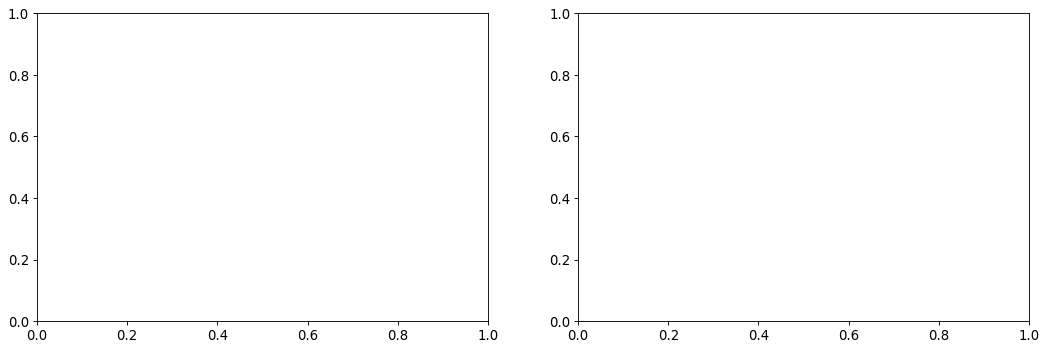

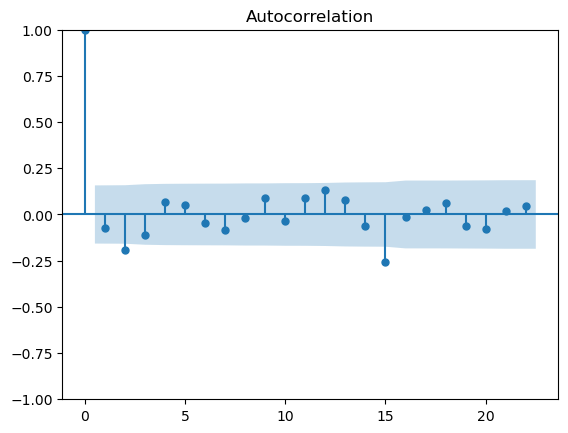

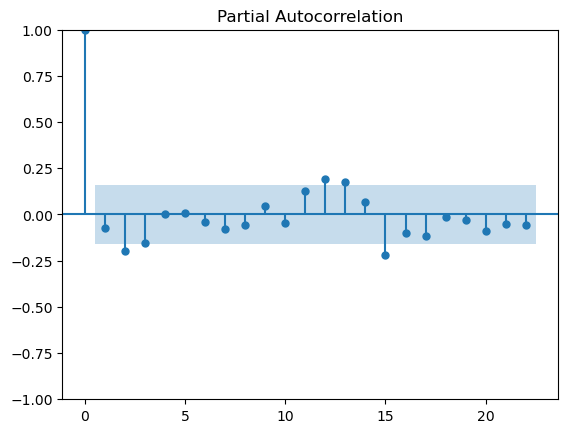

In [8]:
# Import packages
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf

# Plot acf and pacf
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), dpi=80)
plot_acf(data_proc['passenger_diff'])
plot_pacf(data_proc['passenger_diff'], method='ols')
ax1.tick_params(axis='both', labelsize=12)
ax2.tick_params(axis='both', labelsize=12)
plt.show()

In [14]:
from pmdarima import auto_arima

model = auto_arima(data_proc['passenger_diff'], 
                   seasonal=True, 
                   stepwise=True, 
                   trace=True,
                   information_criterion='aic')
model.summary()

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=9226.453, Time=0.04 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=9228.225, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=9229.381, Time=0.00 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=9228.828, Time=0.01 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=9226.460, Time=0.00 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=9225.566, Time=0.02 sec
 ARIMA(0,0,2)(0,0,0)[0] intercept   : AIC=9223.972, Time=0.01 sec
 ARIMA(0,0,3)(0,0,0)[0] intercept   : AIC=9224.373, Time=0.01 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=9227.407, Time=0.02 sec
 ARIMA(1,0,3)(0,0,0)[0] intercept   : AIC=9226.029, Time=0.03 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=9222.409, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=9227.107, Time=0.01 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=9223.697, Time=0.02 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=9222.946, Time=0.01 sec
 ARIMA(1,0,1)(0,0,0)[0]          

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  155
Model:               SARIMAX(0, 0, 2)   Log Likelihood               -4608.204
Date:                Sun, 08 Mar 2026   AIC                           9222.409
Time:                        10:07:42   BIC                           9231.539
Sample:                             0   HQIC                          9226.117
                                - 155                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.1394      0.058     -2.388      0.017      -0.254      -0.025
ma.L2         -0.2007      0.082     -2.441      0.015      -0.362      -0.040
sigma2      4.071e+24        nan        nan        nan         nan         nan
===================================================================================
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):                37.91
Prob(Q):                              0.86   Prob(JB):                         0.00
Heteroskedasticity (H):               2.58   Skew:                             0.28
Prob(H) (two-sided):                  0.00   Kurtosis:                         5.36
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 2.16e+66. Standard errors may be unstable.
"""

In [25]:
# Import packages
from scipy.special import inv_boxcox
from statsmodels.tsa.arima.model import ARIMA

# Split train and test
train = data_proc.iloc[:-int(len(data_proc) * 0.3)]
test = data_proc.iloc[-int(len(data_proc) * 0.3):]

# Build ARIMA model
#model = ARIMA(train['passengers_boxcox'], order=(1, 0, 0),
#              seasonal_order=(1, 1, 1, 52)).fit()
#ARIMA(0,1,0)(0,0,0)[0] 
#SARIMAX(p, d, q)x(P, D, Q, s)
model = ARIMA(train['passengers_boxcox'], order=(0,0,2),
              seasonal_order=(1, 1, 1, 52)).fit()
boxcox_forecasts = model.forecast(len(test))
forecasts = inv_boxcox(boxcox_forecasts, lam)

/Users/icaro/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning:

Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.



In [26]:
# Import packages
import plotly.graph_objects as go

def plot_forecasts(forecasts: list[float], title: str) -> None:
    """Function to plot the forecasts."""
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=train['datetime'], y=train['total_passenger_throughput'], name='Train'))
    fig.add_trace(go.Scatter(x=test['datetime'], y=test['total_passenger_throughput'], name='Test'))
    fig.add_trace(go.Scatter(x=test['datetime'], y=forecasts, name='Forecast'))
    fig.update_layout(template="simple_white", font=dict(size=18), title_text=title,
                      width=650, title_x=0.5, height=400, xaxis_title='Date',
                      yaxis_title='Passengers')

    return fig.show()

# Plot the forecasts
plot_forecasts(forecasts, 'SARIMA')

In [18]:
# Get fourier features
for order in range(1, 104):
    data_proc[f'fourier_sin_order_{order}'] = np.sin(2 * np.pi * order * data_proc['week'] / 52)
    data_proc[f'fourier_cos_order_{order}'] = np.cos(2 * np.pi * order * data_proc['week'] / 52)

# name of fourier features
fourier_features = [i for i in list(data_proc) if i.startswith('fourier')]

# Split train and test
train = data_proc.iloc[:-int(len(data_proc) * 0.3)]
test = data_proc.iloc[-int(len(data_proc) * 0.3):]

# Build auto-ARIMA model with fourier features
model = pm.auto_arima(train['passengers_boxcox'],
                      X=train[fourier_features],
                      seasonal=False,
                      stepwise=True,
                      suppress_warnings=True,
                      max_order=None,
                      information_criterion='aicc',
                      error_action="ignore")

# Get the forecasts and apply inverse box-cox transform
boxcox_forecasts = model.predict(n_periods=len(test), X=test[fourier_features])
forecasts = inv_boxcox(boxcox_forecasts, lam)

In [19]:
def plot_forecasts(forecasts: list[float], title: str) -> None:
    """Function to plot the forecasts."""
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=train['datetime'], y=train['total_passenger_throughput'], name='Train'))
    fig.add_trace(go.Scatter(x=test['datetime'], y=test['total_passenger_throughput'], name='Test'))
    fig.add_trace(go.Scatter(x=test['datetime'], y=forecasts, name='Forecast'))
    fig.update_layout(template="simple_white", font=dict(size=18), title_text=title,
                      width=650, title_x=0.5, height=400, xaxis_title='Date',
                      yaxis_title='Passenger Volume')

    return fig.show()


# Plot the forecasts
plot_forecasts(forecasts, 'Harmonic Regression')